In [1]:
#!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu130

In [2]:
#!pip install Pillow
#!pip install matplotlib
#!pip install tensorflow
#!pip install pandas
#!pip install scikit-learn
#!pip install numpy
#!pip install seaborn

In [3]:
# Importy
from PIL import Image
import os
import zipfile
import random
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tabulate import tabulate
from collections import defaultdict

import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras import Model
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalFocalCrossentropy

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tensorflow.keras.applications.resnet50 import preprocess_input
import torchvision.transforms.v2 as v2
from torchvision import transforms

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

C:\Users\popie\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
print(torch.__version__)
print(torch.version.cuda)
print(torchvision.__version__)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

2.11.0+cu130
13.0
0.26.0+cu130
NVIDIA GeForce RTX 5070 Ti
cuda


In [5]:
# Ustawienie domyślnej kolorystyki wykresów
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set2.colors)
sns.set_palette("Set2")

In [6]:
# Ustawienie seedów
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Załadowanie i preprocesing danych

In [7]:
# Wyświetlenie struktury baz i przykładowe dane w zbiorze
BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd())) 
DATA_DIR = os.path.join(BASE_DIR, "dane")

PAD_DIR = os.path.join(DATA_DIR, "PAD-UFES-20")

metadata_PAD = pd.read_csv(os.path.join(PAD_DIR, "metadata.csv"))

pd.options.display.max_colwidth = 100

print("PAD-UFES-20")
print(metadata_PAD.sample(5))

PAD-UFES-20
     patient_id  lesion_id  smoke  drink background_father background_mother  \
1085   PAT_1186        680    NaN    NaN               NaN               NaN   
2296    PAT_326        690  False  False         POMERANIA         POMERANIA   
208     PAT_547       1033  False  False           GERMANY           GERMANY   
1178    PAT_931       1762  False  False         POMERANIA         POMERANIA   
282    PAT_1981       4023    NaN    NaN               NaN               NaN   

      age pesticide  gender skin_cancer_history  ... diameter_2 diagnostic  \
1085   39       NaN     NaN                 NaN  ...        NaN        NEV   
2296   58      True  FEMALE                True  ...        4.0        BCC   
208    56      True  FEMALE                True  ...        3.0        BCC   
1178   71     False  FEMALE               False  ...        7.0        ACK   
282    79       NaN     NaN                 NaN  ...        NaN        ACK   

       itch   grew   hurt  changed  bl

In [8]:
# Funkcja do unzipowania zdjęć
def unzip(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"ZIP nie istnieje: {zip_path}")
        return
    
    os.makedirs(extract_to, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

In [9]:
unzip(os.path.join(PAD_DIR, "PAD-UFES-20.zip"), PAD_DIR)

In [10]:
# Zapisywanie ścieżek obrazów w kolumnie path 

image_folders_PAD = [
    os.path.join(PAD_DIR, "imgs_part_1"),
    os.path.join(PAD_DIR, "imgs_part_2"),
    os.path.join(PAD_DIR, "imgs_part_3")
]

metadata_PAD['path'] = metadata_PAD['img_id'].apply(
    lambda filename: next(
        (os.path.join(folder, filename) for folder in image_folders_PAD 
         if os.path.exists(os.path.join(folder, filename))),
        None
    )
)

# Sprawdzenie czy wszystko zostało zmapowane
print(metadata_PAD['path'].isna().sum())

0


In [11]:
# Usunięcie uszkodzonych obrazów ze zbiorów
def remove_corrupted(metadata, path_column="path"):
    good_paths = []
    bad_paths = []

    for path in metadata[path_column]:
        try:
            if path is None or not os.path.exists(path):
                bad_paths.append(path)
                continue

            img = Image.open(path)
            img.verify()
            good_paths.append(path)

        except Exception:
            bad_paths.append(path)

    return metadata[metadata[path_column].isin(good_paths)].reset_index(drop=True)

In [12]:
metadata_all = remove_corrupted(metadata_PAD)

In [13]:
print(metadata_PAD.columns)

Index(['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father',
       'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'img_id', 'biopsed', 'path'],
      dtype='str')


In [14]:
metadata_PAD['dataset'] = 'PAD-UFES-20'
metadata_PAD = metadata_PAD[['path', 'dataset', 'diagnostic']].rename(columns={'diagnostic':'dx'})

metadata_all = metadata_PAD
metadata_all = metadata_all.dropna(subset=['dx'])
metadata_all = metadata_all.dropna(subset=["path"])

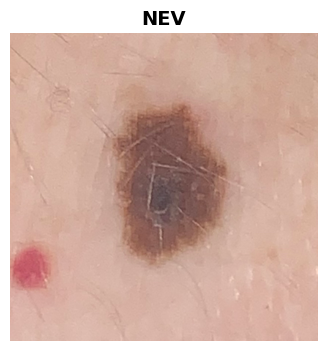

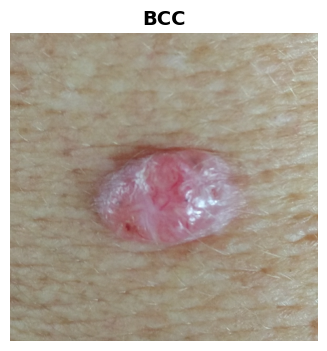

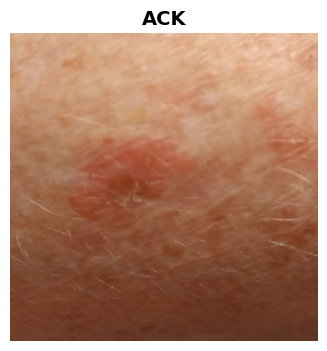

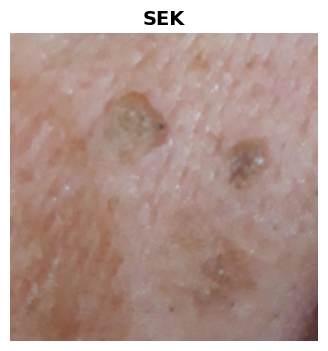

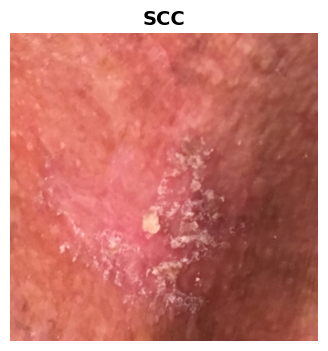

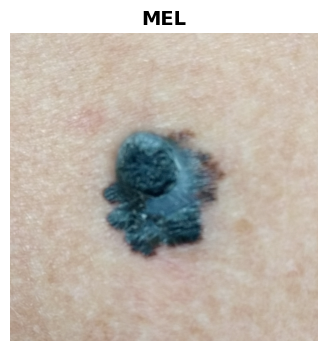

In [15]:
classes = metadata_all["dx"].unique()

for cls in classes:
    subset = metadata_all[metadata_all["dx"] == cls]

    if len(subset) == 0:
        continue

    row = subset.sample(1).iloc[0]

    img = Image.open(row["path"])

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(cls, fontsize=14, fontweight="bold")
    plt.show()


In [16]:
print(metadata_all.sample(20))

                                                                               path  \
1783    C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_1\PAT_460_894_401.png   
1631    C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_1\PAT_135_202_695.png   
496       C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_1\PAT_63_98_187.png   
2168   C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_3\PAT_1304_1081_84.png   
2275    C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_1\PAT_190_291_366.png   
2088   C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_3\PAT_2062_4397_39.png   
1525   C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_2\PAT_945_1796_583.png   
585    C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_2\PAT_596_1146_316.png   
398    C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_3\PAT_1139_523_682.png   
2189  C:\Users\popie\SEM-2025-AP\dane\PAD-UFES-20\imgs_part_3\PAT_1978_4004_304.png   
500   C:\Users\popie\SEM-2025-AP\dane\PAD-U

In [17]:
metadata_all = metadata_all[metadata_all["path"].apply(os.path.exists)]
metadata_all = metadata_all.reset_index(drop=True)

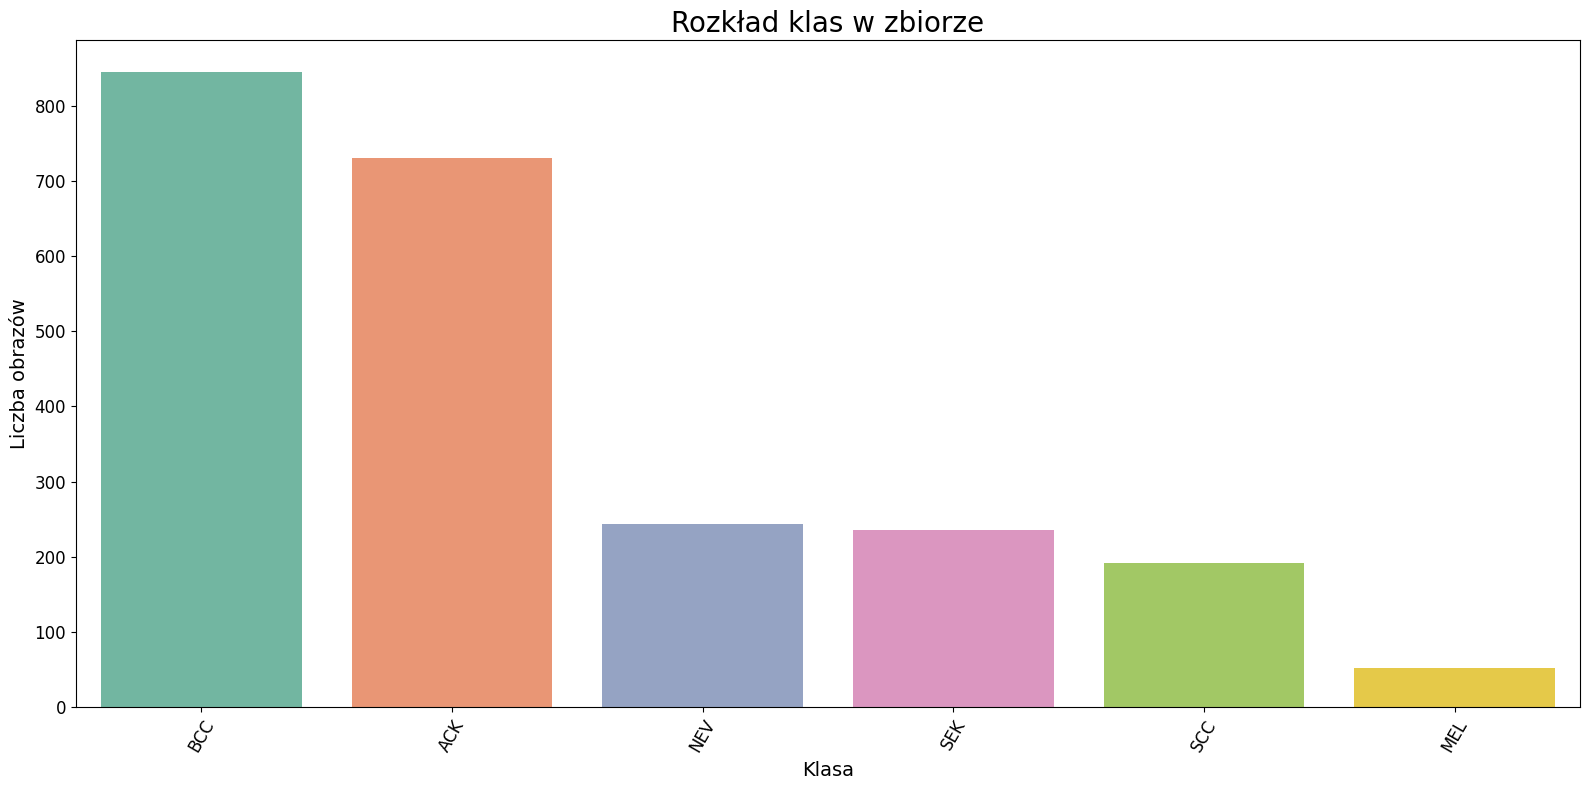

dx
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [18]:
# Wizualizacja dystrybucji klas w zbiorze - wykres słupkowy
class_counts = metadata_all['dx'].value_counts()

plt.figure(figsize=(16, 8))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index
)

plt.title('Rozkład klas w zbiorze', fontsize=20)
plt.xlabel('Klasa', fontsize=14)
plt.ylabel('Liczba obrazów', fontsize=14)
plt.xticks(rotation=60, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
print(class_counts)

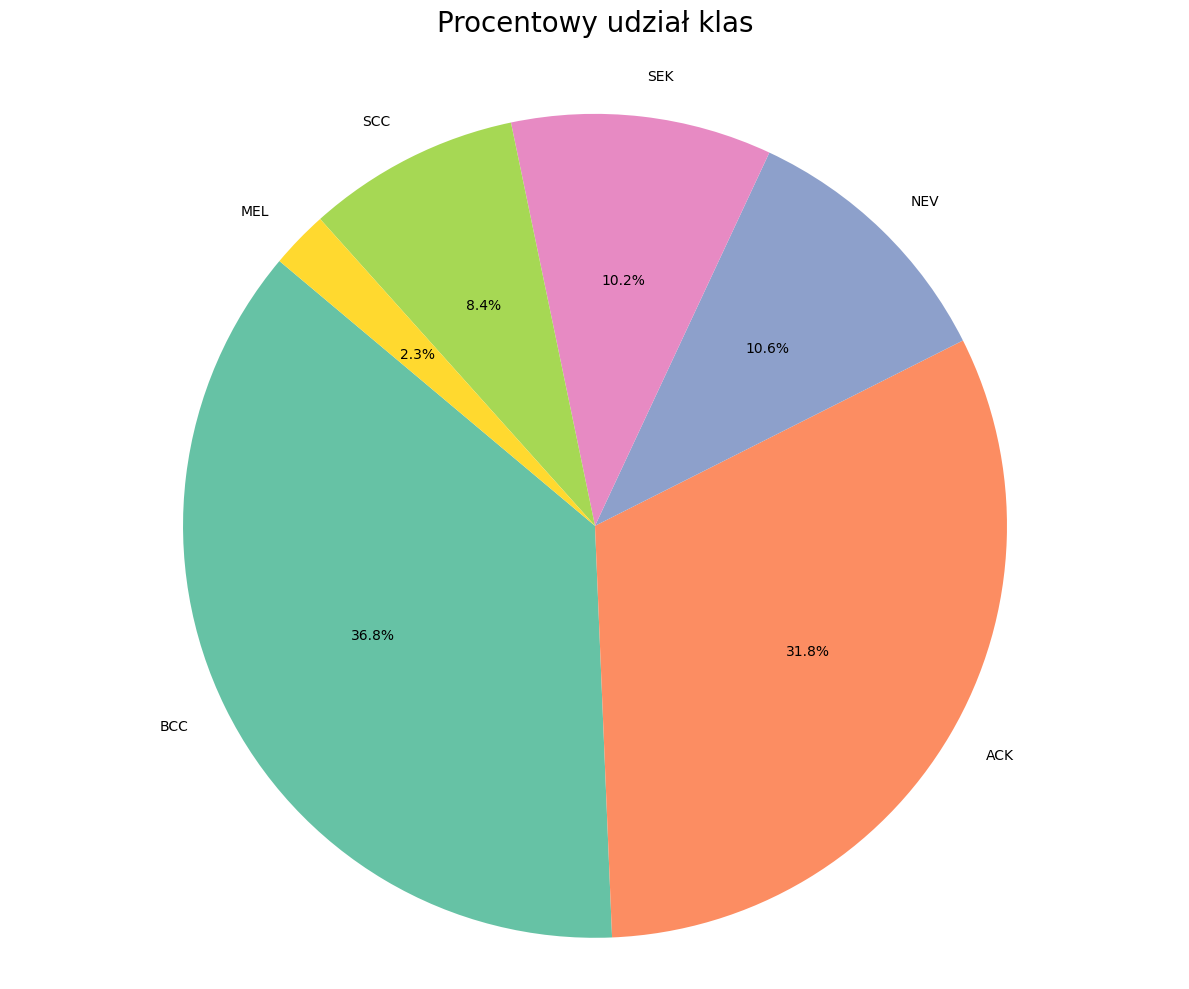

In [19]:
# Wizualizacja dystrybucji klas w zbiorze - wykres kołowy
labels = class_counts.index
sizes = class_counts.values

plt.figure(figsize=(12, 10))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)

plt.title("Procentowy udział klas", fontsize=20, pad=30)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [20]:
# Oversampling klas rzadkich
metadata_balanced = []

for cls, count in metadata_all["dx"].value_counts().items():
    df_cls = metadata_all[metadata_all["dx"] == cls]

    if count < 400:
        df_oversampled = resample(
            df_cls,
            replace=True,
            n_samples=300,
            random_state=42
        )
        metadata_balanced.append(df_oversampled)
    else:
        metadata_balanced.append(df_cls)

metadata_balanced = pd.concat(metadata_balanced).sample(frac=1, random_state=42)
metadata_all = metadata_balanced

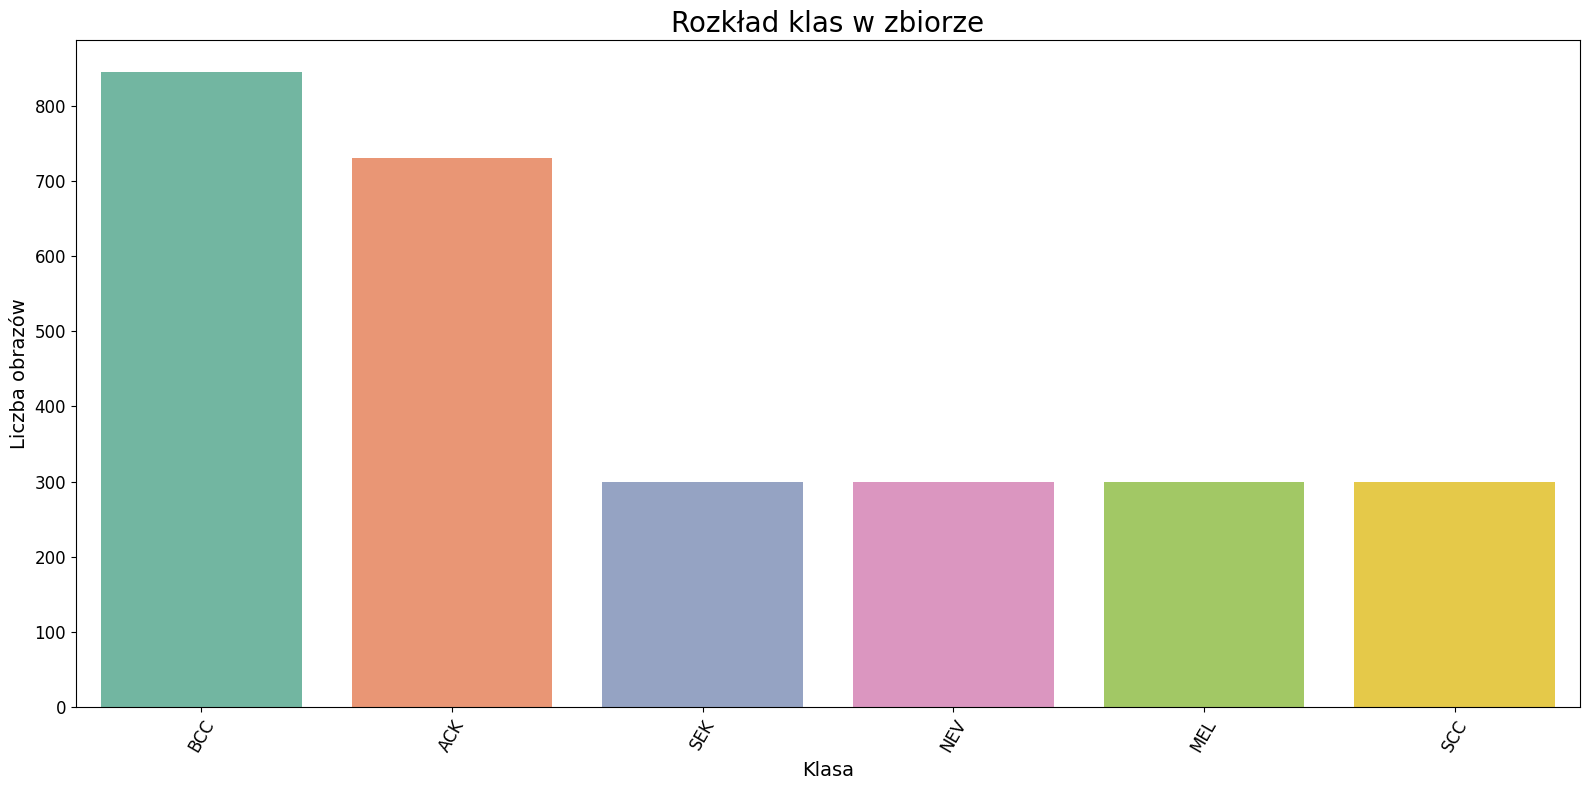

In [21]:
# Wizualizacja dystrybucji klas w zbiorze - wykres słupkowy
class_counts = metadata_all['dx'].value_counts()

plt.figure(figsize=(16, 8))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index
)

plt.title('Rozkład klas w zbiorze', fontsize=20)
plt.xlabel('Klasa', fontsize=14)
plt.ylabel('Liczba obrazów', fontsize=14)
plt.xticks(rotation=60, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

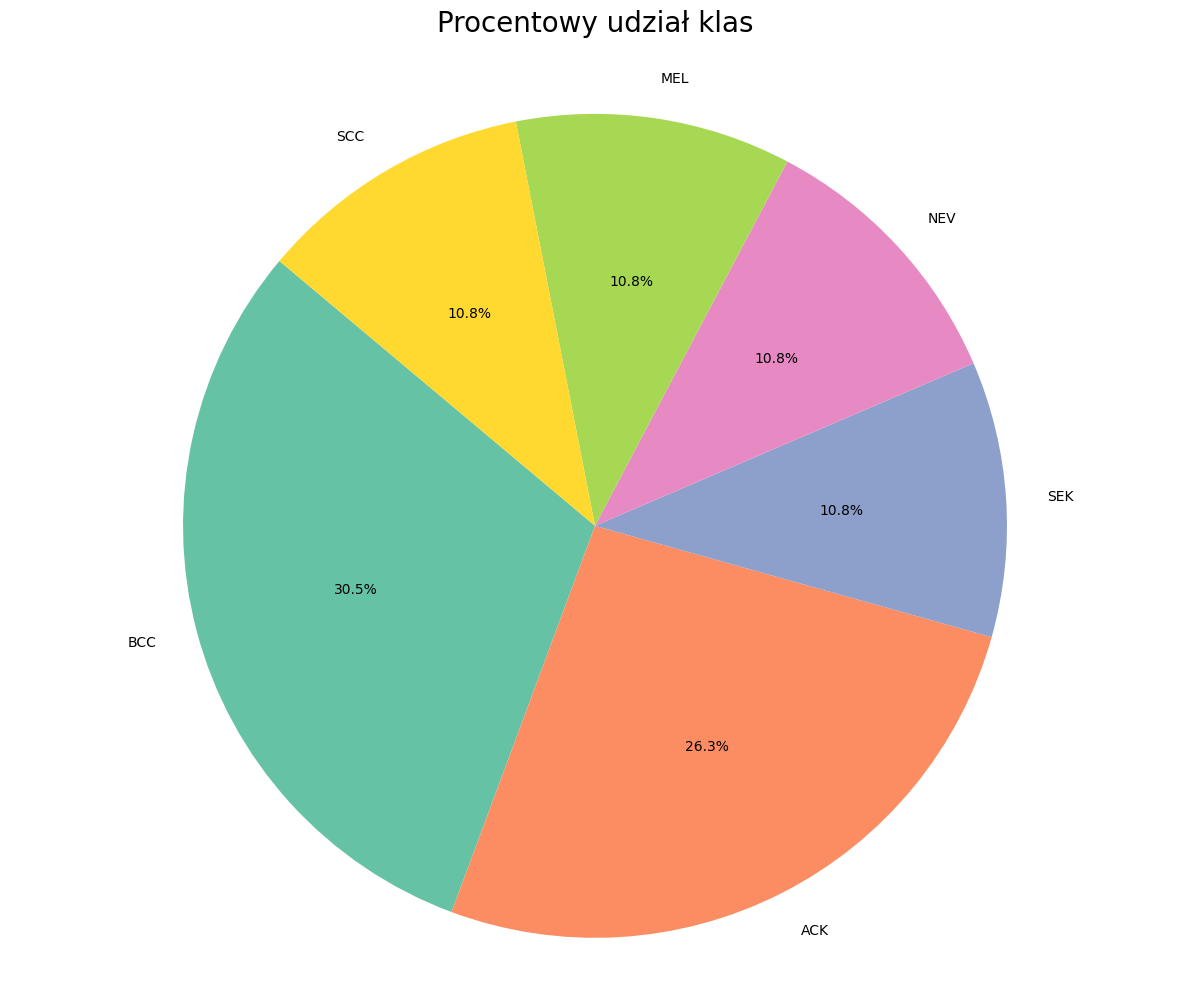

dx
BCC    845
ACK    730
SEK    300
NEV    300
MEL    300
SCC    300
Name: count, dtype: int64


In [22]:
# Wizualizacja dystrybucji klas w zbiorze - wykres kołowy
labels = class_counts.index
sizes = class_counts.values

plt.figure(figsize=(12, 10))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)

plt.title("Procentowy udział klas", fontsize=20, pad=30)
plt.axis('equal')
plt.tight_layout()
plt.show()
print(class_counts)

# Przygotowanie danych do trenowania

In [23]:
train_df, test_df = train_test_split(
    metadata_all,
    test_size=0.2,
    stratify=metadata_all['dx'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['dx'],
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 1998
Val size: 222
Test size: 555


In [24]:
all_classes = sorted(metadata_all['dx'].unique())
NUM_CLASSES = len(all_classes)

print(all_classes)

['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [25]:
# Stworzenie ImageDataGenerator, odpowiedzialnego za przetwarzanie i losową augumentację obrazów podczas trenowania
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,

    horizontal_flip=True,
    vertical_flip=True,

    brightness_range=[0.8, 1.2],

    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [27]:
def mixup(batch_x, batch_y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(batch_x))
    mixed_x = lam * batch_x + (1 - lam) * batch_x[idx]
    mixed_y = lam * batch_y + (1 - lam) * batch_y[idx]
    return mixed_x, mixed_y

In [28]:
def mixup_generator(base_gen, alpha=0.4):
    while True:
        batch_x, batch_y = next(base_gen)
        mixed_x, mixed_y = mixup(batch_x, batch_y, alpha)
        yield mixed_x, mixed_y

In [29]:
# Stworzenie generatorów dostarczających dane (klasa, obraz) podczas trenowania na bazie datagen
IMG_SIZE = 299

base_train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    classes=all_classes,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)

train_generator = mixup_generator(base_train_gen)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    classes=all_classes,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='dx',
    classes=all_classes,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1998 validated image filenames belonging to 6 classes.
Found 222 validated image filenames belonging to 6 classes.
Found 555 validated image filenames belonging to 6 classes.


In [30]:
# Wybrane modele
MODELS = {
    "MobileNetV2": tf.keras.applications.MobileNetV2,
    "MobileNetV3Large": tf.keras.applications.MobileNetV3Large,
    "ResNet50": tf.keras.applications.ResNet50,
    "EfficientNetB0": tf.keras.applications.EfficientNetB0,
    "DenseNet121": tf.keras.applications.DenseNet121,
    "ResNet101": tf.keras.applications.ResNet101,
    "ConvNeXtTiny": tf.keras.applications.ConvNeXtTiny,
}

In [31]:
base_train_gen.class_indices

{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}

# Główna klasa do trenowania modelu

In [32]:
class TransferLearningTuner:
    def __init__(
        self,
        model_name,
        num_classes,
        train_gen,
        val_gen,
        test_gen,
        hidden_units=[128],
        lr_frozen=1e-4,
        lr_unfrozen=2e-5,
        epochs_frozen=3,
        epochs_unfrozen=7,
        dropout_rate=0.3,
        base_train_gen=None,
    ):
        self.model_name = model_name
        self.num_classes = num_classes
        self.train_gen = train_gen
        self.val_gen = val_gen
        self.test_gen = test_gen
        self.hidden_units = hidden_units
        self.lr_frozen = lr_frozen
        self.lr_unfrozen = lr_unfrozen
        self.epochs_frozen = epochs_frozen
        self.epochs_unfrozen = epochs_unfrozen
        self.dropout_rate = dropout_rate
        self.base_train_gen = base_train_gen

        self.model = self.build_model()

    def build_model(self):
        base = MODELS[self.model_name](
            weights="imagenet",
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )

        base.trainable = False
        self.base = base

        x = tf.keras.layers.GlobalAveragePooling2D()(base.output)

        for units in self.hidden_units:
            x = tf.keras.layers.Dense(units, activation="relu")(x)
            x = tf.keras.layers.BatchNormalization()(x)
            x = tf.keras.layers.Dropout(self.dropout_rate)(x)

        output = tf.keras.layers.Dense(self.num_classes, activation="softmax")(x)

        return tf.keras.Model(inputs=base.input, outputs=output)

    def train_frozen(self):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(self.lr_frozen),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
            metrics=["accuracy", tf.keras.metrics.AUC()]
        )

        ckpt = tf.keras.callbacks.ModelCheckpoint(
            f"{self.model_name}_frozen.weights.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True
        )

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )

        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            cooldown=2,
            min_lr=1e-7,
            verbose=1
        )

        history = self.model.fit(
            self.train_gen,
            validation_data=self.val_gen,
            steps_per_epoch=len(self.base_train_gen),
            epochs=self.epochs_frozen,
            callbacks=[ckpt, early_stopping, reduce_lr]
        )

        self.model.load_weights(f"{self.model_name}_frozen.weights.h5")
        return history
     
    def train_unfrozen(self):
        fine_tune_at = int(len(self.base.layers) * 0.7)

        for i, layer in enumerate(self.base.layers):
            if i < fine_tune_at or isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(self.lr_unfrozen),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
            metrics=["accuracy", tf.keras.metrics.AUC()]
        )

        ckpt = tf.keras.callbacks.ModelCheckpoint(
            f"{self.model_name}_unfrozen.weights.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True
        )

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )

        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            cooldown=2,
            min_lr=1e-7,
            verbose=1
        )

        history = self.model.fit(
            self.train_gen,
            validation_data=self.val_gen,
            steps_per_epoch=len(self.base_train_gen),
            epochs=self.epochs_unfrozen,
            callbacks=[ckpt, early_stopping, reduce_lr]
        )

        self.model.load_weights(f"{self.model_name}_unfrozen.weights.h5")
        return history


    def evaluate(self):
        return self.model.evaluate(self.test_gen)

    def plot_confusion_matrix(self, y_true, y_pred, labels, title):
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels, yticklabels=labels)
        plt.title(title)
        plt.ylabel("True class")
        plt.xlabel("Predicted class")
        plt.show()

    def predict_generator(self, generator):
        preds = self.model.predict(generator, verbose=0)
        y_true = generator.classes
        y_pred = np.argmax(preds, axis=1)
        return y_true, y_pred

    def compute_f1_per_class(self, y_true, y_pred, labels):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        f1 = f1_score(
            y_true,
            y_pred,
            average=None,
            labels=list(range(len(labels))),
            zero_division=0
        )

        df = pd.DataFrame({"class": labels, "f1": f1})
        return df

    def plot_loss(self, history, name):
        """
        Drukuje wykres straty i dokładności dla treningu i walidacji
        """
        plt.figure(figsize=(12, 8))
        epochs = range(1, len(history.history["loss"]) + 1)
        
        plt.plot(epochs, history.history["loss"], label="train_loss")
        plt.plot(epochs, history.history["val_loss"], label="val_loss")
        plt.plot(epochs, history.history["accuracy"], label="train_acc")
        plt.plot(epochs, history.history["val_accuracy"], label="val_acc")
        
        plt.title(f"Strata i dokładność trenowania – {name}")
        plt.xlabel("Epoka")
        plt.ylabel("Loss / Accuracy")
        plt.legend()
        plt.show()
        
    def run(self):
        print(f"\n{self.model_name}: Etap 1 (Frozen)")
        history_frozen = self.train_frozen()

        print(f"\n{self.model_name}: Etap 2 (Fine-tuning)")
        history_unfrozen = self.train_unfrozen()

        print("\n=== Wyniki ===")
        results = self.evaluate()

        labels = list(self.val_gen.class_indices.keys())

        y_true, y_pred= self.predict_generator(self.val_gen)
        f1_val = self.compute_f1_per_class(y_true, y_pred, labels)

        return {
            "results": results,
            "history_frozen": history_frozen,
            "history_unfrozen": history_unfrozen,
            "f1_val": f1_val
        }

In [33]:
all_results = []

# ResNet50

In [34]:
MODEL_NAME = "ResNet50"

tuner = TransferLearningTuner(
    model_name="ResNet50",
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[256],
    lr_frozen=1e-4,
    lr_unfrozen=2e-5,
    epochs_frozen=5,
    epochs_unfrozen=7,
    dropout_rate=0.3,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})


ResNet50: Etap 1 (Frozen)
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3043 - auc: 0.5926 - loss: 2.0782 - val_accuracy: 0.4820 - val_auc: 0.7930 - val_loss: 1.4391 - learning_rate: 1.0000e-04
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.4414 - auc: 0.6627 - loss: 1.6947 - val_accuracy: 0.4775 - val_auc: 0.8298 - val_loss: 1.3398 - learning_rate: 1.0000e-04
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5110 - auc: 0.6828 - loss: 1.5596 - val_accuracy: 0.5450 - val_auc: 0.8678 - val_loss: 1.2169 - learning_rate: 1.0000e-04
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5070 - auc: 0.7000 - loss: 1.5501 - val_accuracy: 0.5586 - val_auc: 0.8707 - val_loss: 1.2080 - learning_rate: 1.0000e-04
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5561 - auc: 0.7189 - loss: 1.4459 - val_accuracy: 0.5811 - val_auc: 0.8926 - val_loss: 1.1232 - learning_rate: 1.0000e-04

ResNet50: Etap 2 (Fine-tuning)
Epoch 1/7
63/63 

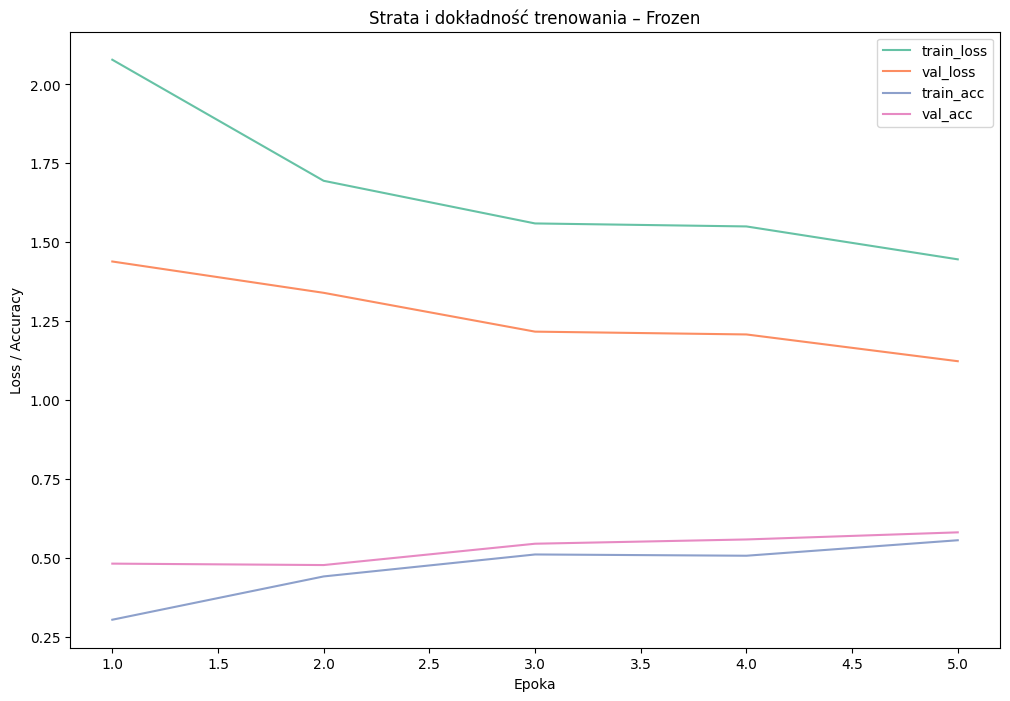

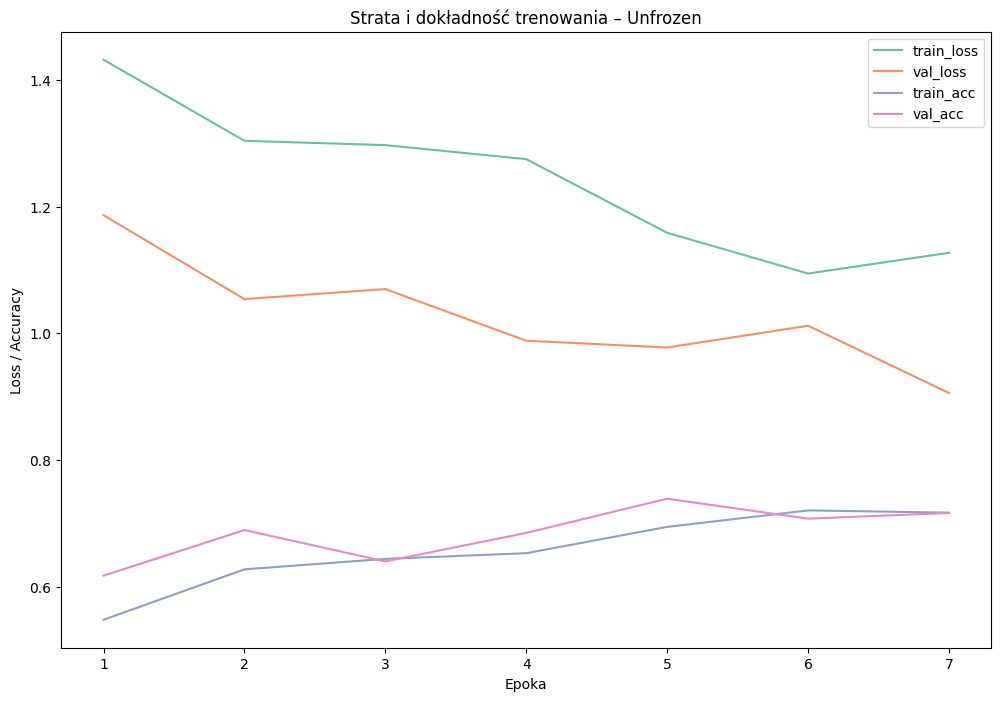

In [35]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [36]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_ResNet50\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_ResNet50\assets


Saved artifact at 'models/skin_lesion_model_ResNet50'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2733443476048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443474896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443475472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443475280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443477584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443475088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443475664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443473168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443472784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443472400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443474320: Te

# MobileNetV2

In [37]:
MODEL_NAME="MobileNetV2"

tuner = TransferLearningTuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[512, 128],
    epochs_frozen=5,
    epochs_unfrozen=4,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})

C:\Users\popie\AppData\Local\Temp\ipykernel_27024\254834119.py:33: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MODELS[self.model_name](



MobileNetV2: Etap 1 (Frozen)
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2012 - auc_2: 0.5327 - loss: 2.4703 - val_accuracy: 0.2928 - val_auc_2: 0.6618 - val_loss: 1.6841 - learning_rate: 1.0000e-04
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2578 - auc_2: 0.5650 - loss: 2.2741 - val_accuracy: 0.2748 - val_auc_2: 0.6485 - val_loss: 1.7122 - learning_rate: 1.0000e-04
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.2682 - auc_2: 0.5842 - loss: 2.1840 
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 980ms/step - accuracy: 0.2518 - auc_2: 0.5821 - loss: 2.1717 - val_accuracy: 0.3468 - val_auc_2: 0.6717 - val_loss: 1.6879 - learning_rate: 1.0000e-04
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 949ms/step - accuracy: 0.2933 - auc_2: 0.5929 - loss: 2.0989 - val_accuracy: 0.3378 - val_auc_2: 0.6737 - val_loss: 1.7025 - learning_rate: 5.0000e-05
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s

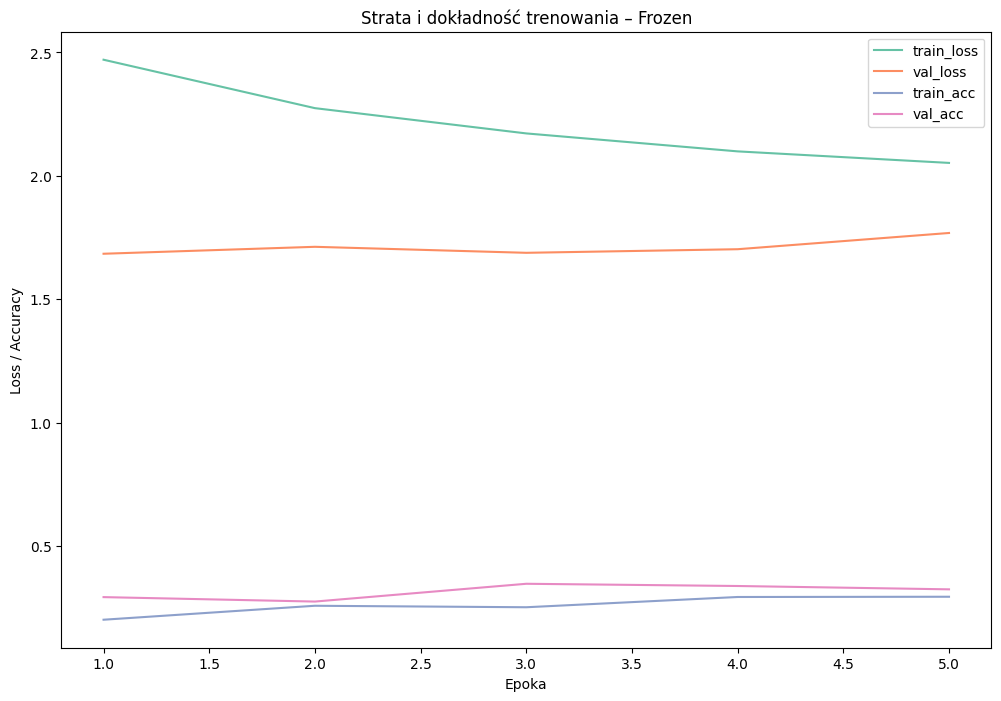

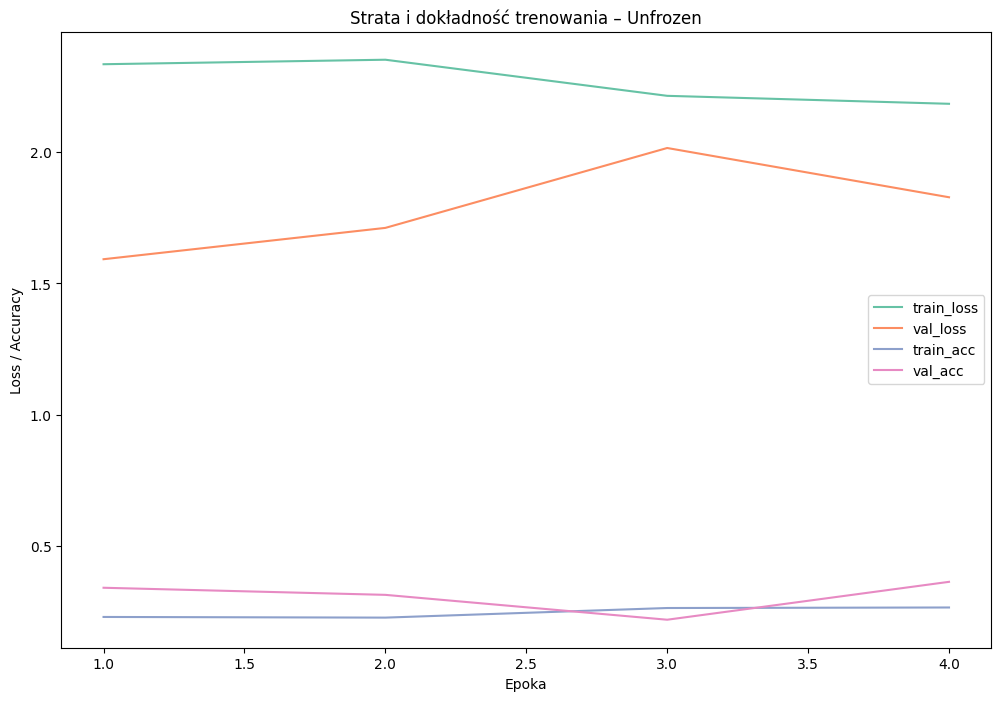

In [38]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [39]:
# Zapis i konwersja modelu na wersję TFLite
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_MobileNetV2\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_MobileNetV2\assets


Saved artifact at 'models/skin_lesion_model_MobileNetV2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_192')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2723013470032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013460624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013473296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013466000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013460240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013474640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013473680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013476176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013462928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013473872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723013460

# DenseNet121

In [40]:
MODEL_NAME="DenseNet121"

tuner = TransferLearningTuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[256, 64],
    epochs_frozen=8,
    epochs_unfrozen=10,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})


DenseNet121: Etap 1 (Frozen)
Epoch 1/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.2357 - auc_4: 0.5430 - loss: 2.3449 - val_accuracy: 0.2072 - val_auc_4: 0.5430 - val_loss: 2.0296 - learning_rate: 1.0000e-04
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.2568 - auc_4: 0.5770 - loss: 2.1541 - val_accuracy: 0.2793 - val_auc_4: 0.6394 - val_loss: 1.8523 - learning_rate: 1.0000e-04
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.2978 - auc_4: 0.5833 - loss: 2.0507 - val_accuracy: 0.3468 - val_auc_4: 0.6869 - val_loss: 1.7780 - learning_rate: 1.0000e-04
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3228 - auc_4: 0.6020 - loss: 1.9600 - val_accuracy: 0.3243 - val_auc_4: 0.6943 - val_loss: 1.7704 - learning_rate: 1.0000e-04
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3068 - auc_4: 0.5936 - loss: 2.0088 - val_accuracy: 0.3649 - val_auc_4: 0.7210 - val_loss: 1.7076 - learning_rate: 1.0000e-04
Epoch 6/8
63/63 ━━━━━━━━━

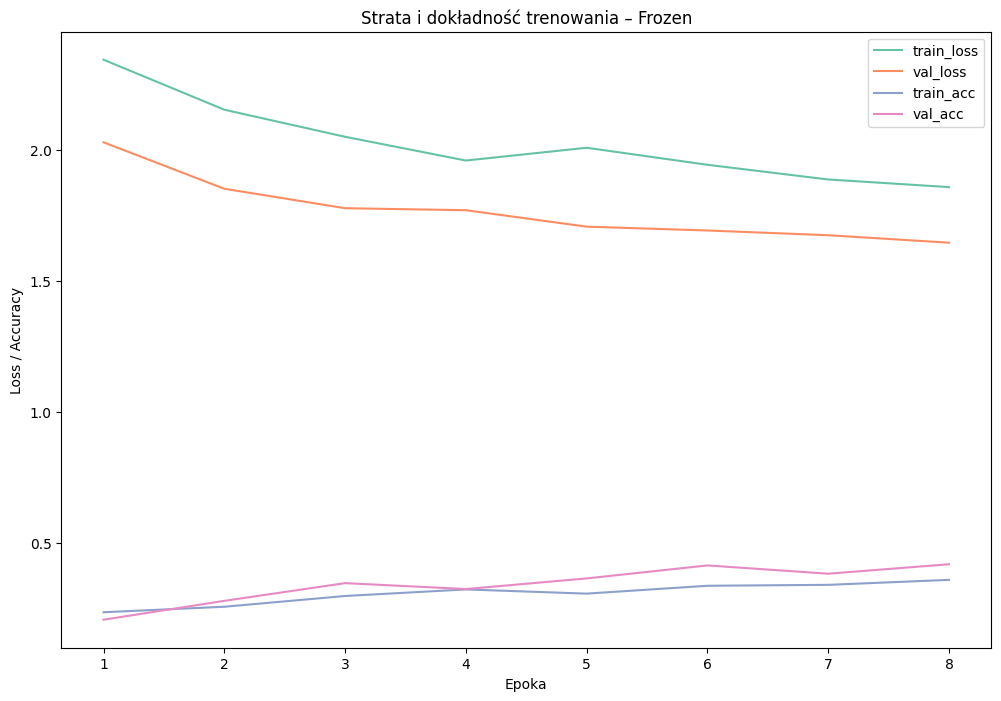

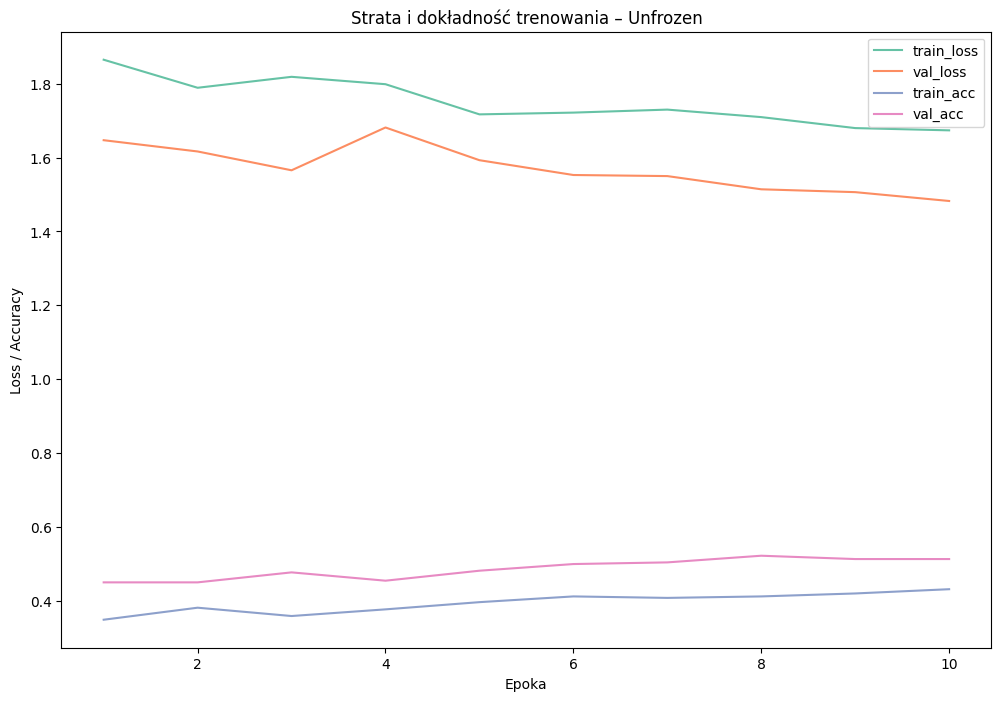

In [41]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [42]:
# Zapis i konwersja modelu na wersję TFLite
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_DenseNet121\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_DenseNet121\assets


Saved artifact at 'models/skin_lesion_model_DenseNet121'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_366')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2733443472976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443467408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443466832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443470096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443467024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2724745890512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2724745902992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443473552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733443471248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2724745901456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2723067204

# MobileNetV3Large

In [43]:
MODEL_NAME = "MobileNetV3Large"

tuner = TransferLearningTuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[128],
    lr_frozen=1e-4,
    lr_unfrozen=2e-5,
    epochs_frozen=3,
    epochs_unfrozen=7,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})

C:\Users\popie\anaconda3\Lib\site-packages\keras\src\applications\mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(



MobileNetV3Large: Etap 1 (Frozen)
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.2032 - auc_6: 0.5269 - loss: 2.3918 - val_accuracy: 0.3063 - val_auc_6: 0.6601 - val_loss: 1.7451 - learning_rate: 1.0000e-04
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 971ms/step - accuracy: 0.2918 - auc_6: 0.5772 - loss: 2.0458 - val_accuracy: 0.4414 - val_auc_6: 0.7460 - val_loss: 1.5631 - learning_rate: 1.0000e-04
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 932ms/step - accuracy: 0.3318 - auc_6: 0.6102 - loss: 1.8744 - val_accuracy: 0.4595 - val_auc_6: 0.7685 - val_loss: 1.5137 - learning_rate: 1.0000e-04

MobileNetV3Large: Etap 2 (Fine-tuning)
Epoch 1/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.3934 - auc_7: 0.6381 - loss: 1.7723 - val_accuracy: 0.4820 - val_auc_7: 0.7815 - val_loss: 1.5056 - learning_rate: 2.0000e-05
Epoch 2/7
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 987ms/step - accuracy: 0.3999 - auc_7: 0.6375 - loss: 1.7228 - val_accuracy: 0.4730 - val_auc_7: 0.7961 - val_loss: 1.4590

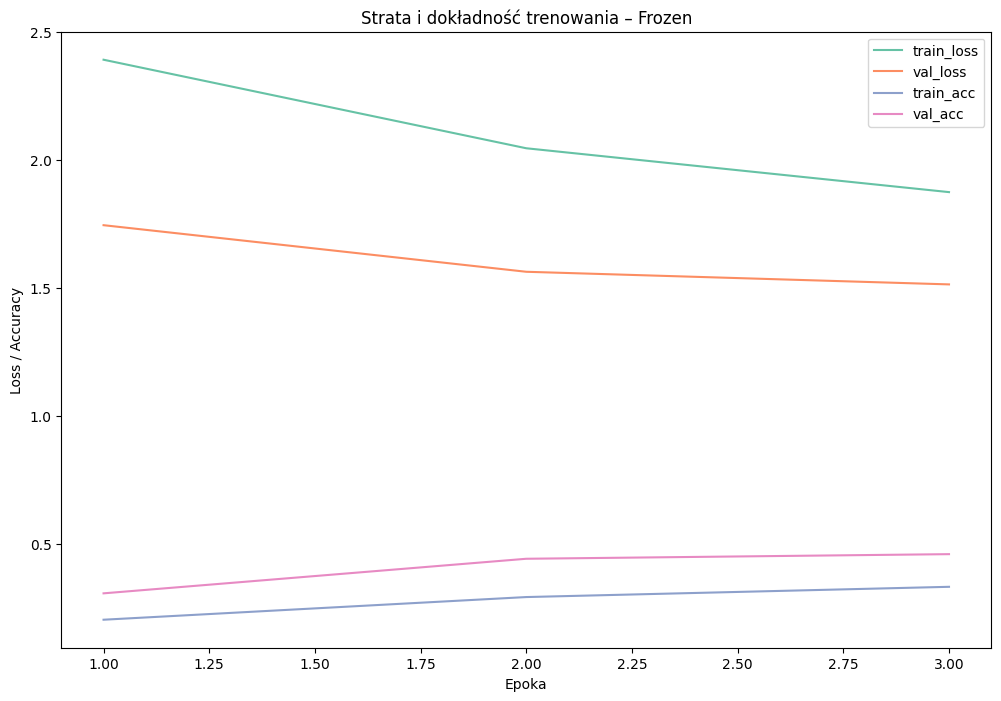

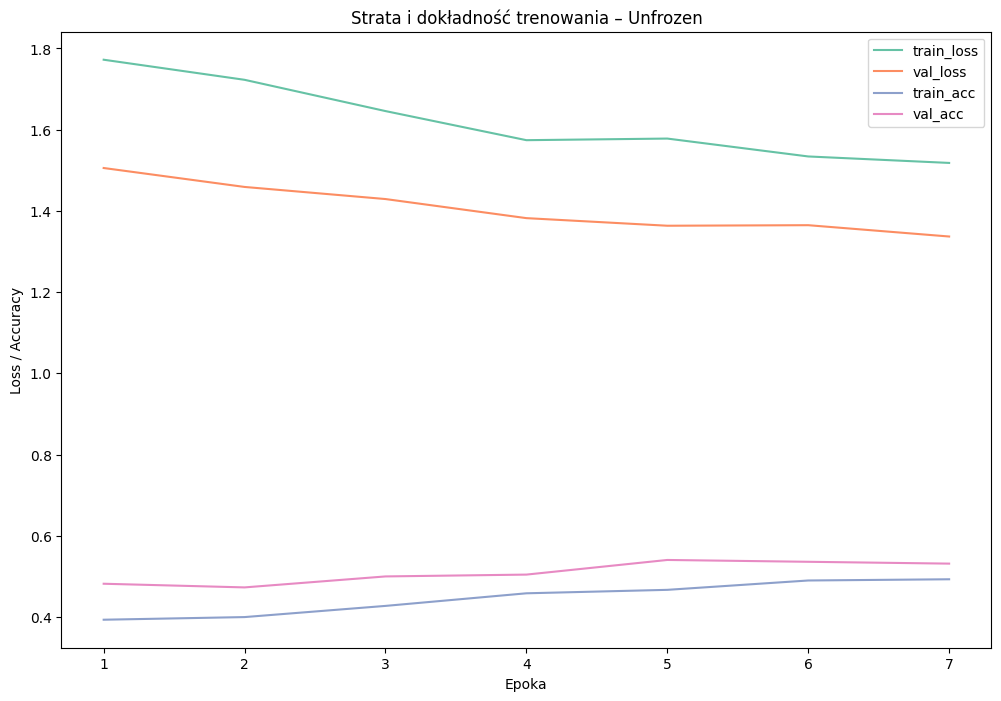

In [44]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [45]:
# Zapis i konwersja modelu na wersję TFLite
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_MobileNetV3Large\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_MobileNetV3Large\assets


Saved artifact at 'models/skin_lesion_model_MobileNetV3Large'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_813')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2733789886800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789882960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789884112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789887568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789882192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789888144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789885648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789885456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789873360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2733789886992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27337

# EfficientNetB0

In [46]:
MODEL_NAME="EfficientNetB0"

tuner = TransferLearningTuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[256],
    epochs_frozen=5,
    epochs_unfrozen=5,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})


EfficientNetB0: Etap 1 (Frozen)
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.2513 - auc_8: 0.5442 - loss: 2.2074 - val_accuracy: 0.2117 - val_auc_8: 0.6285 - val_loss: 1.7278 - learning_rate: 1.0000e-04
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.3203 - auc_8: 0.5928 - loss: 1.9602 - val_accuracy: 0.2973 - val_auc_8: 0.6965 - val_loss: 1.6462 - learning_rate: 1.0000e-04
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.3408 - auc_8: 0.6142 - loss: 1.8630 - val_accuracy: 0.4189 - val_auc_8: 0.7532 - val_loss: 1.5531 - learning_rate: 1.0000e-04
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.3834 - auc_8: 0.6379 - loss: 1.7828 - val_accuracy: 0.4595 - val_auc_8: 0.7686 - val_loss: 1.5067 - learning_rate: 1.0000e-04
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4124 - auc_8: 0.6474 - loss: 1.7188 - val_accuracy: 0.4865 - val_auc_8: 0.7921 - val_loss: 1.4474 - learning_rate: 1.0000e-04

EfficientNetB0: Etap 

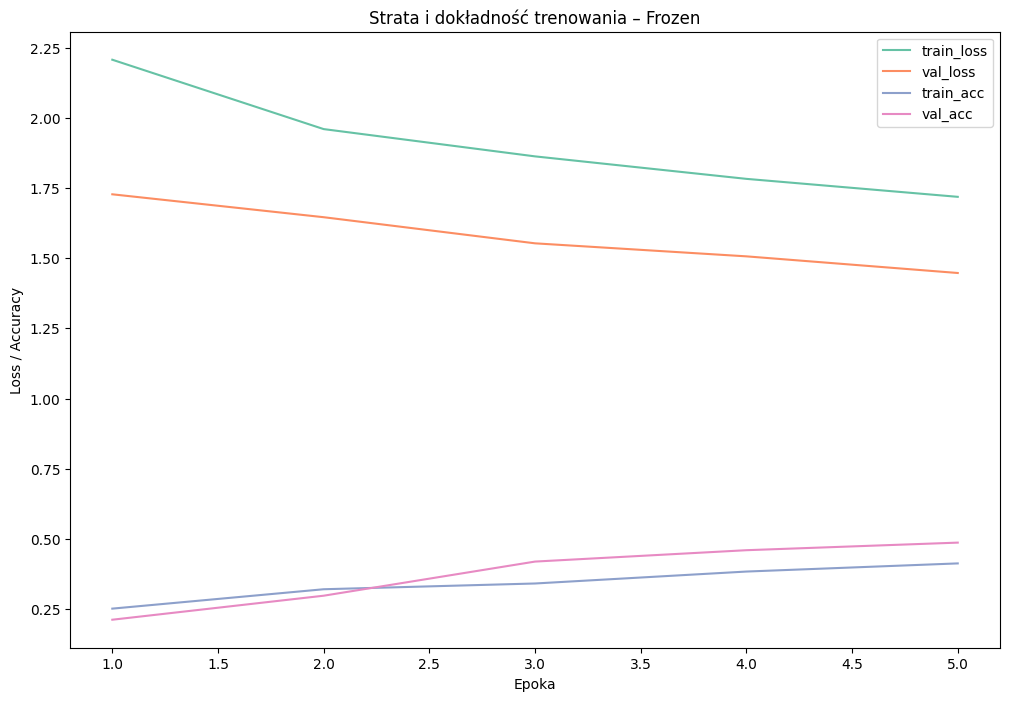

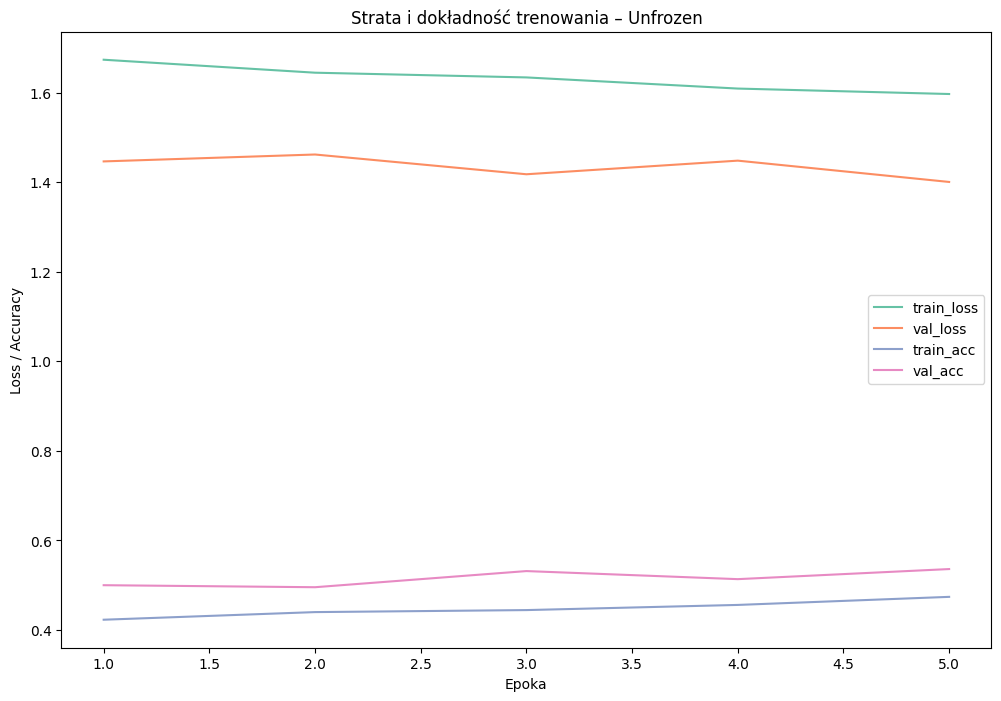

In [47]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [48]:
# Zapis i konwersja modelu na wersję TFLite
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_EfficientNetB0\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_EfficientNetB0\assets


Saved artifact at 'models/skin_lesion_model_EfficientNetB0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_1033')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2738448606480: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2738448605328: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2737570166352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570164816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570167312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570165392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570159248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570164624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570165200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2737570167504: TensorSpec(shape=(), dtype=tf.resource, n

# ConvNeXtTiny

In [49]:
MODEL_NAME="ConvNeXtTiny"

tuner = TransferLearningTuner(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[256],
    epochs_frozen=5,
    epochs_unfrozen=5,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})


ConvNeXtTiny: Etap 1 (Frozen)
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.1927 - auc_10: 0.5145 - loss: 2.4332 - val_accuracy: 0.2342 - val_auc_10: 0.5646 - val_loss: 1.7858 - learning_rate: 1.0000e-04
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.2733 - auc_10: 0.5707 - loss: 2.1375 - val_accuracy: 0.2883 - val_auc_10: 0.6485 - val_loss: 1.6915 - learning_rate: 1.0000e-04
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.3458 - auc_10: 0.6082 - loss: 1.9579 - val_accuracy: 0.3649 - val_auc_10: 0.7057 - val_loss: 1.6095 - learning_rate: 1.0000e-04
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.3669 - auc_10: 0.6255 - loss: 1.8091 - val_accuracy: 0.4414 - val_auc_10: 0.7519 - val_loss: 1.5233 - learning_rate: 1.0000e-04
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - accuracy: 0.4029 - auc_10: 0.6491 - loss: 1.7632 - val_accuracy: 0.4640 - val_auc_10: 0.7741 - val_loss: 1.4818 - learning_rate: 1.0000e-04

ConvNeXt

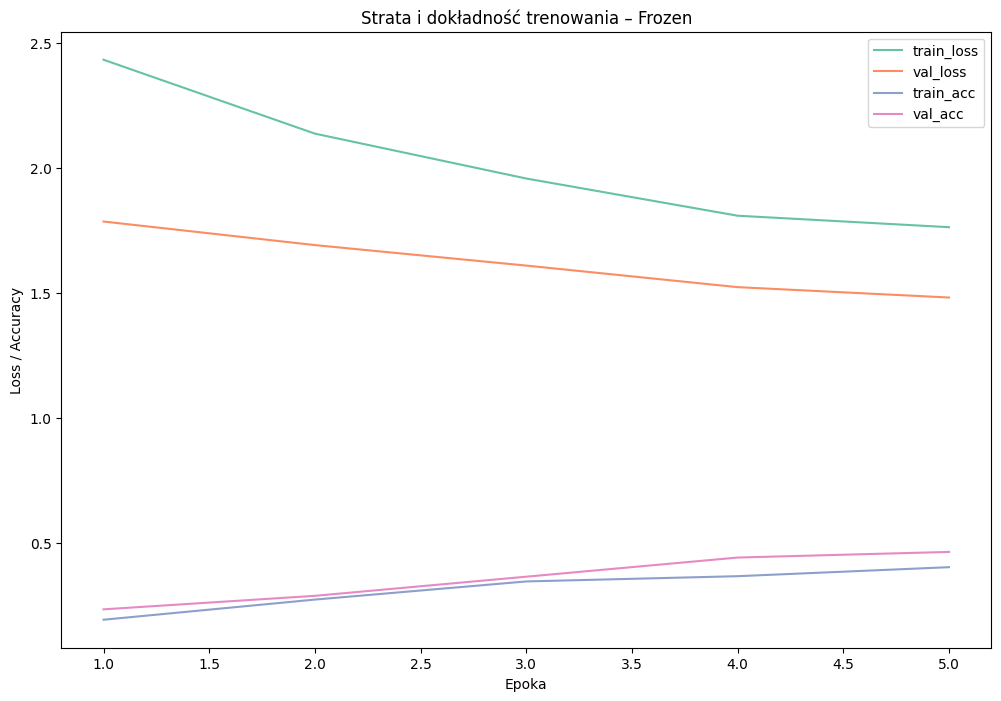

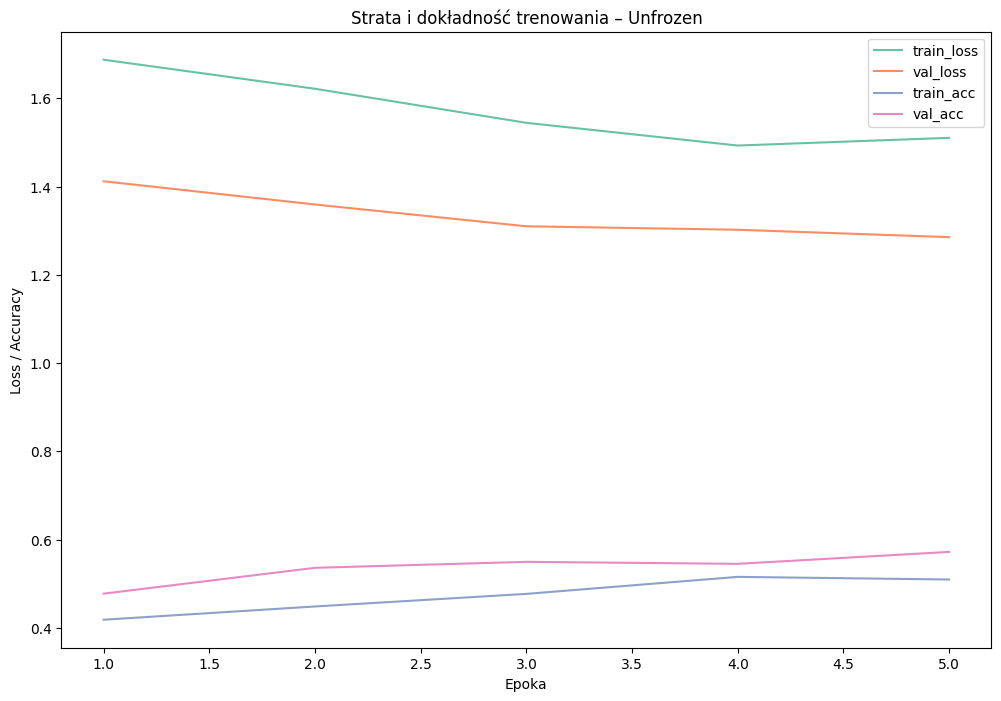

In [50]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [51]:
# Zapis i konwersja modelu na wersję TFLite
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_ConvNeXtTiny\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_ConvNeXtTiny\assets


Saved artifact at 'models/skin_lesion_model_ConvNeXtTiny'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_1288')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2739448663504: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2739448674640: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2739448663120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448664656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448663312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448664464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448664080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448665424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448676176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739448665232: TensorSpec(shape=(), dtype=tf.resource, nam

# ResNet101

In [52]:
MODEL_NAME="ResNet101"

tuner = TransferLearningTuner(
    model_name="ResNet101",
    num_classes=NUM_CLASSES,
    train_gen=train_generator,
    val_gen=val_generator,
    test_gen=test_generator,
    hidden_units=[256],
    lr_frozen=1e-4,
    lr_unfrozen=1.5e-5,
    epochs_frozen=6,
    epochs_unfrozen=8,
    dropout_rate=0.35,
    base_train_gen=base_train_gen
)

out = tuner.run()

results = out["results"]
f1_val = out["f1_val"]

all_results.append({
    "model": MODEL_NAME,
    "test_loss": results[0],
    "test_acc": results[1],
    "test_auc": results[2],
    "f1_val": f1_val
})


ResNet101: Etap 1 (Frozen)
Epoch 1/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.2983 - auc_12: 0.5840 - loss: 2.1286 - val_accuracy: 0.4144 - val_auc_12: 0.7172 - val_loss: 1.6392 - learning_rate: 1.0000e-04
Epoch 2/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.4099 - auc_12: 0.6625 - loss: 1.7961 - val_accuracy: 0.4685 - val_auc_12: 0.7971 - val_loss: 1.4402 - learning_rate: 1.0000e-04
Epoch 3/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.4665 - auc_12: 0.6787 - loss: 1.6832 - val_accuracy: 0.5450 - val_auc_12: 0.8408 - val_loss: 1.3219 - learning_rate: 1.0000e-04
Epoch 4/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5025 - auc_12: 0.6942 - loss: 1.5930 - val_accuracy: 0.5586 - val_auc_12: 0.8423 - val_loss: 1.3313 - learning_rate: 1.0000e-04
Epoch 5/6
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5157 - auc_12: 0.7048 - loss: 1.5021  
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s

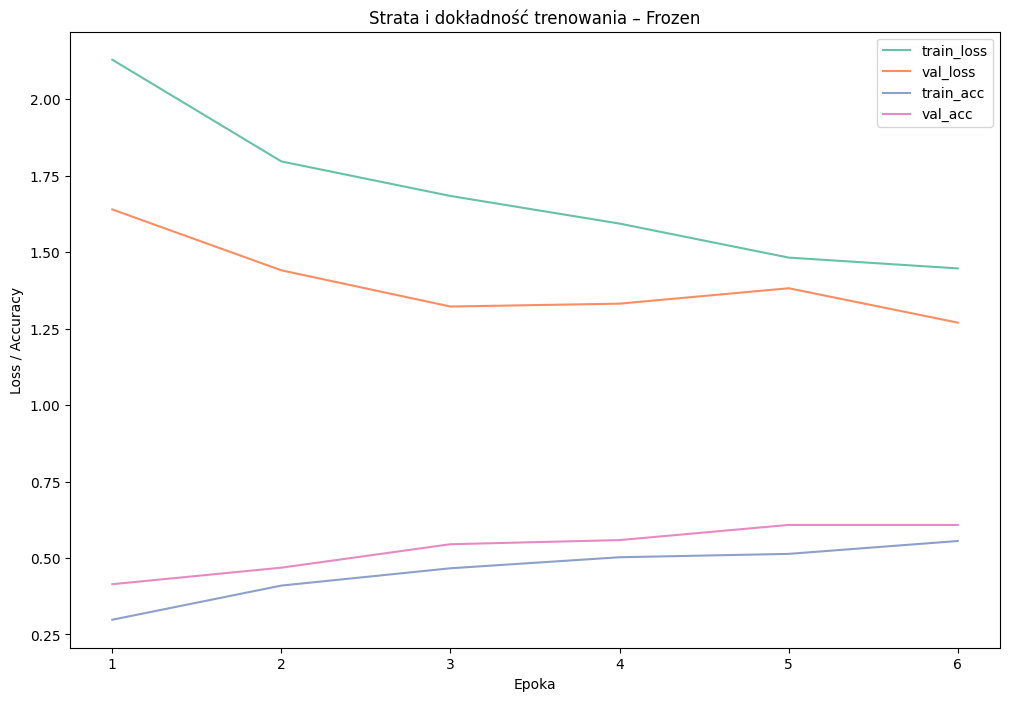

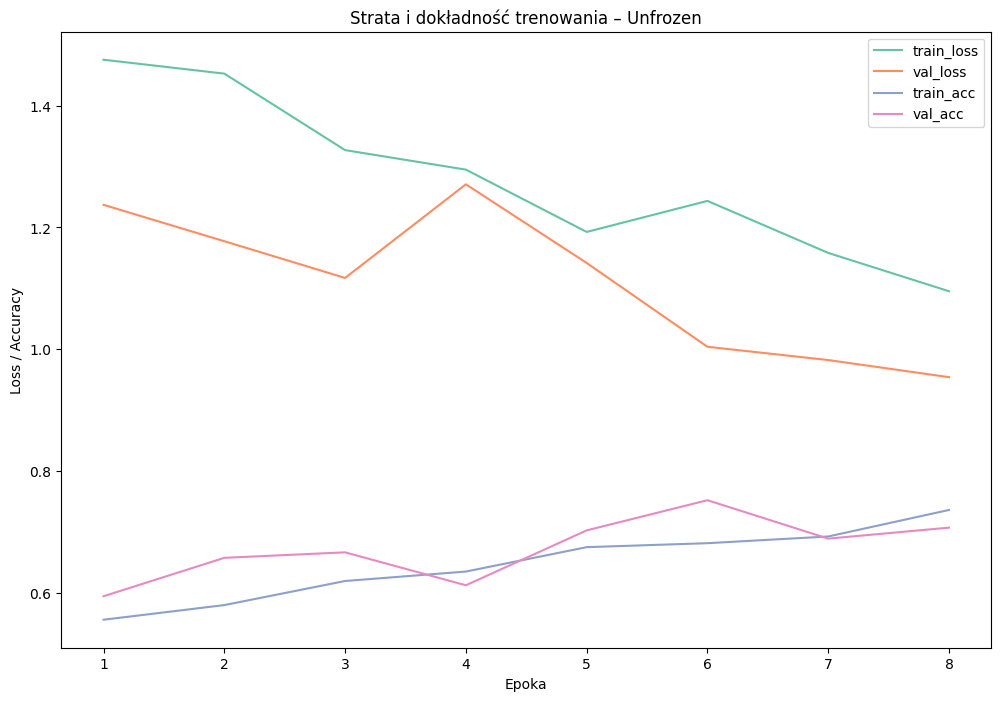

In [53]:
tuner.plot_loss(out["history_frozen"], "Frozen")
tuner.plot_loss(out["history_unfrozen"], "Unfrozen")

In [54]:
# Zapis i konwersja modelu na wersję TFLite
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

tuner.model.export(f"models/skin_lesion_model_{MODEL_NAME}")

converter = tf.lite.TFLiteConverter.from_saved_model(
    f"models/skin_lesion_model_{MODEL_NAME}"
)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
with open(f"tflite_models/skin_lesion_model_{MODEL_NAME}.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: models/skin_lesion_model_ResNet101\assets


INFO:tensorflow:Assets written to: models/skin_lesion_model_ResNet101\assets


Saved artifact at 'models/skin_lesion_model_ResNet101'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='keras_tensor_1468')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2739716618384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739716618960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739345654032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739345653840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739716617616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739716618000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739345655760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739345656720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739345656336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2739345656144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  27393456542

# Raport końcowy

In [55]:
df_report = pd.DataFrame(all_results)

df_report["mean_f1_val"] = df_report["f1_val"].apply(
    lambda df: pd.to_numeric(df["f1"], errors="coerce").mean()
)

df_report[[
    "model",
    "test_loss",
    "test_acc",
    "test_auc",
    "mean_f1_val"
]]

,model,test_loss,test_acc,test_auc,mean_f1_val
0,ResNet50,0.921086,0.740541,0.936294,0.720347
1,MobileNetV2,1.578974,0.367568,0.731209,0.244268
2,DenseNet121,1.442507,0.470270,0.792956,0.431988
3,MobileNetV3Large,1.262453,0.565766,0.856405,0.497864
4,EfficientNetB0,1.317639,0.535135,0.841971,0.485276
5,ConvNeXtTiny,1.269826,0.589189,0.852376,0.565678
6,ResNet101,0.913247,0.767568,0.937928,0.713752


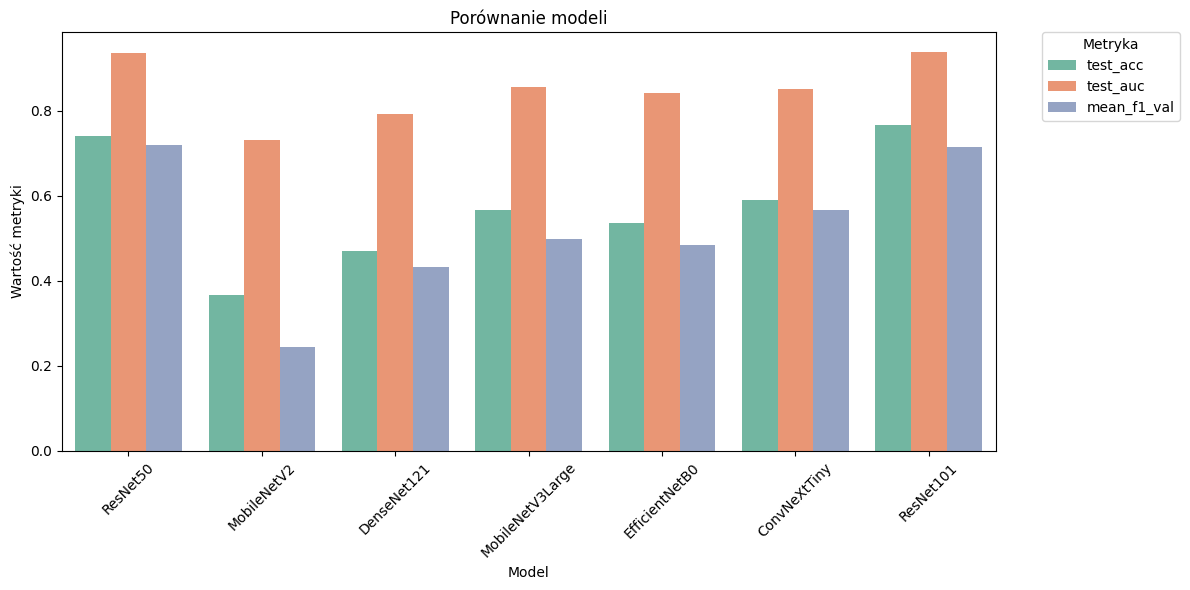

In [56]:
plt.figure(figsize=(12, 6))

df_melt = df_report.melt(
    id_vars="model",
    value_vars=["test_acc", "test_auc", "mean_f1_val"],
    var_name="metric",
    value_name="value"
)

sns.barplot(data=df_melt, x="model", y="value", hue="metric")
plt.title("Porównanie modeli")
plt.ylabel("Wartość metryki")
plt.xlabel("Model")
plt.xticks(rotation=45)

plt.legend(
    title="Metryka",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

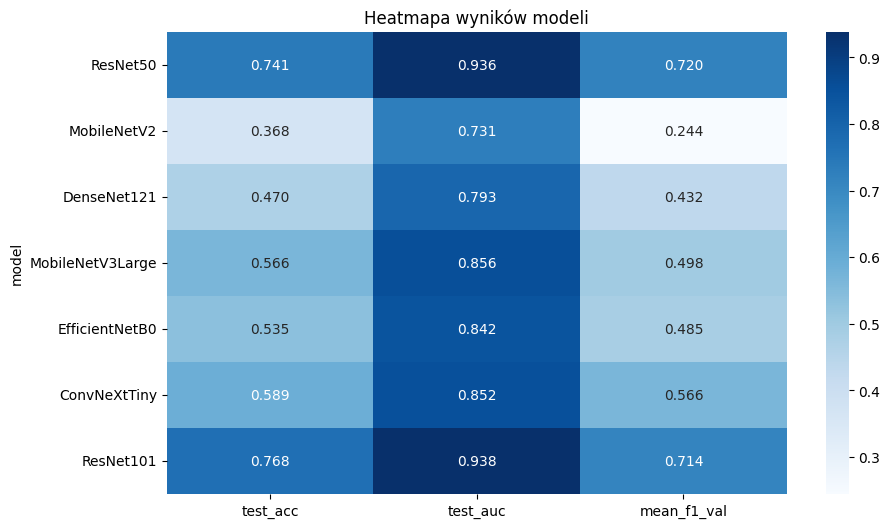

In [57]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df_report.set_index("model")[[
        "test_acc",
        "test_auc",
        "mean_f1_val"
    ]],
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Heatmapa wyników modeli")
plt.show()

In [60]:
f1_tables = []

for entry in all_results:
    model = entry["model"]
    df_f1 = entry["f1_val"].copy()
    df_f1["model"] = model
    f1_tables.append(df_f1)

df_f1_all = pd.concat(f1_tables, ignore_index=True)
df_f1_all = df_f1_all[["model", "class", "f1"]]

df_f1_pivot = df_f1_all.pivot_table(
    index="class",
    columns="model",
    values="f1"
)


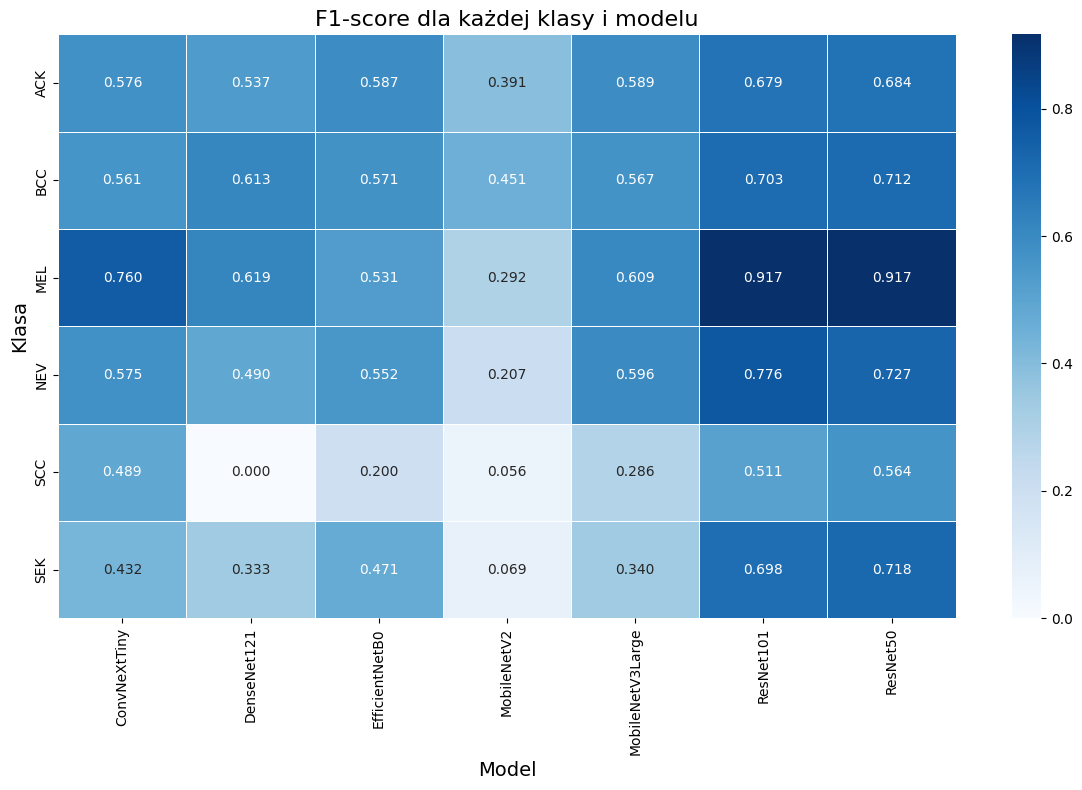

In [61]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_f1_pivot.sort_index(),
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white"
)

plt.title("F1-score dla każdej klasy i modelu", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Klasa", fontsize=14)
plt.tight_layout()
plt.show()